# Day 2 — Data prep + Logistic Regression baseline

1. Feature engineering (numeric vs. categorical split, imputation, encoding)
2. Stratified train/holdout split — holdout is locked from here on, not touched again until Day 4's final eval
3. Logistic Regression baseline, honestly reported (no imbalance handling yet — that's Day 3)

In [1]:
import sys, json
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
    confusion_matrix, classification_report, precision_recall_curve
)

from src.data import load_merged_train
from src.features import get_feature_lists, build_preprocessor

RANDOM_STATE = 42

In [2]:
train = load_merged_train()
print(train.shape)

(590540, 434)


## 1. Feature engineering

Kept deliberately simple for a baseline:
- **Numeric**: `TransactionAmt`, `card1/2/3/5`, `addr1/2`, `dist1/2`, `C1-C14`, `D1-D15`, `V1-V339`, `id_01-id_11` — imputed with train-median, then standard-scaled (LogReg needs scaling to converge properly).
- **Categorical**: `ProductCD`, `card4`, `card6`, `P_emaildomain`, `R_emaildomain`, `M1-M9`, `DeviceType` — missing values become their own `"missing"` category, then one-hot encoded.
- **Dropped for baseline**: `TransactionID` (identifier, not signal), `DeviceInfo` and `id_12-id_38` (high-cardinality + very sparse per Day 1 EDA — revisit for the Day 3 tree model, which handles this better than LogReg).
- **All imputers/encoders/scalers are fit on the training split only** and applied to the holdout — no leakage.

In [3]:
numeric_features, categorical_features = get_feature_lists(train)

print(f'{len(numeric_features)} numeric features, {len(categorical_features)} categorical features')

X = train[numeric_features + categorical_features]
y = train['isFraud']

388 numeric features, 15 categorical features


## 2. Stratified train/holdout split

80/20, stratified on `isFraud` so both splits keep the ~3.5% fraud rate. The holdout `TransactionID`s are saved to disk so every later day evaluates against the *exact same* holdout — it is not touched again until Day 4's final locked eval.

In [4]:
X_train, X_holdout, y_train, y_holdout, id_train, id_holdout = train_test_split(
    X, y, train['TransactionID'],
    test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('train:', X_train.shape, 'fraud rate:', y_train.mean().round(4))
print('holdout:', X_holdout.shape, 'fraud rate:', y_holdout.mean().round(4))

split_ids = {
    'random_state': RANDOM_STATE,
    'test_size': 0.2,
    'train_ids': id_train.tolist(),
    'holdout_ids': id_holdout.tolist(),
}
with open('../data/processed/split_ids.json', 'w') as f:
    json.dump(split_ids, f)

print('Saved locked holdout split to data/processed/split_ids.json')

train: (472432, 403) fraud rate: 0.035
holdout: (118108, 403) fraud rate: 0.035


Saved locked holdout split to data/processed/split_ids.json


## 3. Logistic Regression baseline

Plain LogReg, default class weights — deliberately **not** correcting for the 3.5% imbalance yet. That correction (class weights / SMOTE) is scoped to Day 3 alongside the XGBoost model. Reporting the plain baseline honestly shows *why* Day 3's imbalance handling is needed.

In [5]:
preprocessor = build_preprocessor(numeric_features, categorical_features)

model = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

model.fit(X_train, y_train)
print('Fitted.')

Fitted.


In [6]:
y_proba = model.predict_proba(X_holdout)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

precision = precision_score(y_holdout, y_pred)
recall = recall_score(y_holdout, y_pred)
f1 = f1_score(y_holdout, y_pred)
pr_auc = average_precision_score(y_holdout, y_proba)

print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1:        {f1:.4f}')
print(f'PR-AUC:    {pr_auc:.4f}')
print()
print(classification_report(y_holdout, y_pred, target_names=['not fraud', 'fraud']))

Precision: 0.8157
Recall:    0.2688
F1:        0.4044
PR-AUC:    0.4711

              precision    recall  f1-score   support

   not fraud       0.97      1.00      0.99    113975
       fraud       0.82      0.27      0.40      4133

    accuracy                           0.97    118108
   macro avg       0.89      0.63      0.70    118108
weighted avg       0.97      0.97      0.97    118108



Confusion matrix (rows=actual, cols=predicted):
[[113724    251]
 [  3022   1111]]


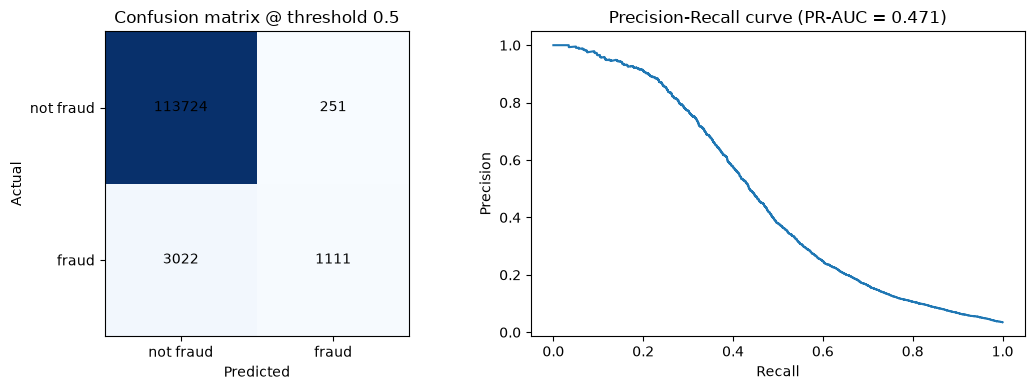

In [7]:
cm = confusion_matrix(y_holdout, y_pred)
print('Confusion matrix (rows=actual, cols=predicted):')
print(cm)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['not fraud', 'fraud'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['not fraud', 'fraud'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion matrix @ threshold 0.5')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center')

prec_curve, rec_curve, _ = precision_recall_curve(y_holdout, y_proba)
axes[1].plot(rec_curve, prec_curve)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall curve (PR-AUC = {pr_auc:.3f})')

plt.tight_layout()
plt.show()

## Save baseline metrics for tracking across days

In [8]:
metrics = {
    'model': 'LogisticRegression (baseline, no imbalance handling)',
    'threshold': 0.5,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'pr_auc': pr_auc,
    'confusion_matrix': cm.tolist(),
    'n_train': len(X_train),
    'n_holdout': len(X_holdout),
}

with open('../results/baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved to results/baseline_metrics.json')
metrics

Saved to results/baseline_metrics.json


{'model': 'LogisticRegression (baseline, no imbalance handling)',
 'threshold': 0.5,
 'precision': 0.815712187958884,
 'recall': 0.26881200096782,
 'f1': 0.4043676069153776,
 'pr_auc': 0.471149306274944,
 'confusion_matrix': [[113724, 251], [3022, 1111]],
 'n_train': 472432,
 'n_holdout': 118108}

## Takeaway

_Fill in after running: precision/recall/PR-AUC at threshold 0.5, and whether recall is low due to the class imbalance (expected — motivates Day 3's class-weight/SMOTE handling and the move to XGBoost)._